## Financial Fraud Detection using Decision Tree Machine Learning Models
In this notebook, we will showcase the use of decision tree ML models to perform financial fraud detection.

Original NB : https://pages.databricks.com/rs/094-YMS-629/images/financial-fraud-detection-decision-tree.html?_ga=2.261331150.2112692442.1591844546-225663068.1585060489

### Source Data
PaySim simulates mobile money transactions based on a sample of real transactions extracted from one month of financial logs from a mobile money service implemented in an African country. The original logs were provided by a multinational company, who is the provider of the mobile financial service which is currently running in more than 14 countries all around the world.

This synthetic dataset is scaled down 1/4 of the original dataset and it is created just for Kaggle. To load the dataset yourself, please download it to your local machine from Kaggle and then import the data via Import Data: Azure | AWS.



### Dictionary
This is the column definition of the referenced sythentic dataset.


| Column Name      | Description                                                                                                                        |
|------------------|------------------------------------------------------------------------------------------------------------------------------------|
| step             | maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).                |
| type             | CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.                                                                                    |
| amount           | amount of the transaction in local currency.                                                                                       |
| nameOrig         | customer who started the transaction                                                                                               |
| oldbalanceOrg    | initial balance before the transaction                                                                                             |
| newbalanceOrig   | new balance after the transaction                                                                                                  |
| nameDest         | customer who is the recipient of the transaction                                                                                   |
| oldbalanceDest   | initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).  |
| newbalanceDest   | new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).       |

In [0]:
# Including MLflow
import mlflow
import mlflow.spark

import os
print("MLflow Version: %s" % mlflow.__version__)

MLflow Version: 3.5.1


In [0]:
from pyspark.dbutils import DBUtils
from datetime import date, datetime, timedelta
import pyspark.sql.functions as F
from pytz import timezone
import logging

logger = logging.getLogger('FRAUD DETECTION')
logger.propagate = False # Prevent log messages from being passed to the root logger
logger.handlers = []
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

# create the stderr handler
stderr_handler = logging.StreamHandler()
stderr_handler.setLevel(logging.DEBUG)
stderr_handler.setFormatter(formatter)
logger.addHandler(stderr_handler)
logger.setLevel(logging.DEBUG)
logger.info(f"Start logging ...")
logger.info(f"Spark version: {spark.version}")

2025-11-07 17:17:37,913 - INFO - Start logging ...
2025-11-07 17:17:37,914 - INFO - Spark version: 3.5.0


In [0]:
dbutils.widgets.removeAll()

In [0]:
# Changed per environment
dbutils.widgets.text("env", "prodfix")
env = dbutils.widgets.get("env")

# databricks workspace value
dbutils.widgets.text("short_code", "gci")
short_code = dbutils.widgets.get("short_code")

# Configure storage account connection
sp_name = f"p-{env}-ds-{short_code}-svcp" 
secret_scope = f"{short_code}-secrets"
client_id_name = f"{sp_name}-client-id"
client_secret_name = f"{sp_name}-secret"

storage_access_list = ["prodfixdseus2tgcisa01"]

# Setting the spark configuration
for sa in storage_access_list:
  spark.conf.set(f"fs.azure.account.auth.type.{sa}.dfs.core.windows.net", "OAuth")
  spark.conf.set(f"fs.azure.account.oauth.provider.type.{sa}.dfs.core.windows.net", "org.apache.hadoop.fs.azurebfs.oauth2.ClientCredsTokenProvider")
  spark.conf.set(f"fs.azure.account.oauth2.client.id.{sa}.dfs.core.windows.net", dbutils.secrets.get(scope=secret_scope, key=client_id_name))
  spark.conf.set(f"fs.azure.account.oauth2.client.secret.{sa}.dfs.core.windows.net", dbutils.secrets.get(scope=secret_scope, key=client_secret_name))
  spark.conf.set(f"fs.azure.account.oauth2.client.endpoint.{sa}.dfs.core.windows.net", "https://login.microsoftonline.com/92cb778e-8ba7-4f34-a011-4ba6e7366996/oauth2/token")

# Identify the databricks workspace environment
WrkSpaceId= spark.conf.get("spark.databricks.clusterUsageTags.clusterOwnerOrgId")
 
if(WrkSpaceId=='2195848036328367'):  
  env='prod'
elif(WrkSpaceId=='1851115442125419'):  
  env='prodfix'
elif(WrkSpaceId=='6340613744706656'):
  env='qa'
 
logger.info(f"Environment: {env}")

2025-11-07 17:17:42,844 - INFO - Environment: prodfix


In [0]:
fraudulent_transactions_df = spark.read.csv("/FileStore/tables/archive_01.csv", header=True, inferSchema=True, sep=",")
# fraudulent_transactions_df = spark.read.csv("/FileStore/tables/archive.csv", header=True, inferSchema=True, sep=",")
# fraudulent_transactions_df = spark.read.format("csv").option("header", True).option("inferSchema", True).option("sep", ",").load("abfss://csgci-adhoc@prodfixdseus2tgcisa01.dfs.core.windows.net/db_use_case_files/archive_01.csv.zip")

df = fraudulent_transactions_df.select("step", "type", "amount", "nameOrig", "oldbalanceOrg", "newbalanceOrig", "nameDest", "oldbalanceDest", "newbalanceDest")

df.display()
df.count() # 8,808, 6,362,620

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0
1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0
1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0
1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0
1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0
1,PAYMENT,7107.77,C154988899,183195.0,176087.23,M408069119,0.0,0.0
1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.0
1,PAYMENT,4024.36,C1265012928,2671.0,0.0,M1176932104,0.0,0.0
1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79


6362620

In [0]:
# Review the schema of your data 
df.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)



## Calculate Differences between Originating and Destination Balanaces
With the following PySpark DataFrame query, we will calculate the following columns:

In [0]:
# Calculate the differences between originating and destination balances
df = df.withColumn("orgDiff", df.newbalanceOrig - df.oldbalanceOrg).withColumn("destDiff", df.newbalanceDest - df.oldbalanceDest)

# Create temporary view
df.createOrReplaceTempView("financials")

## Let's review the data and ask some simple questions

In [0]:
display(df)

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,orgDiff,destDiff
1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,-9839.640000000014,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,-1864.2799999999988,0.0
1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,-181.0,0.0
1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,-181.0,-21182.0
1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,-11668.14,0.0
1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,-7817.709999999999,0.0
1,PAYMENT,7107.77,C154988899,183195.0,176087.23,M408069119,0.0,0.0,-7107.7699999999895,0.0
1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.0,-7861.640000000014,0.0
1,PAYMENT,4024.36,C1265012928,2671.0,0.0,M1176932104,0.0,0.0,-2671.0,0.0
1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,-5337.769999999997,-1549.2099999999991


## What are the type of transactions?

In [0]:
%sql
-- Organize by Type
select type, count(1) from financials group by type

type,count(1)
TRANSFER,532909
CASH_IN,1399284
CASH_OUT,2237500
PAYMENT,2151495
DEBIT,41432


Databricks visualization. Run in Databricks to view.

## How much money are we talking about (synthetically)?

In [0]:
%sql
select type, sum(amount) from financials group by type

type,sum(amount)
TRANSFER,4.8529198726317017E11
CASH_IN,2.3636739191245993E11
CASH_OUT,3.9441299522448975E11
PAYMENT,2.809337113836999E10
DEBIT,2.2719922128E8


Databricks visualization. Run in Databricks to view.

## Rules-based Model: Create a set of rules to identify fraud based on known cases
The following where clause are a set of rules to identify know fraud-based cases using SQL; i.e. rules-based model.

- Often, financial fraud analytics start with with clauses like the where clause below
- Note, in reality, rules are often much larger and more complicated

In [0]:
from pyspark.sql import functions as F

# Rules to Identify Known Fraud-based
df = df.withColumn("label", 
                   F.when(
                     (
                       (df.oldbalanceOrg <= 56900) & (df.type == "TRANSFER") & (df.newbalanceDest <= 105)) | 
                       (
                         (df.oldbalanceOrg > 56900) & (df.newbalanceOrig <= 12)) | 
                           (
                             (df.oldbalanceOrg > 56900) & (df.newbalanceOrig > 12) & (df.amount > 1160000)
                           ), 1
                   ).otherwise(0))

# Calculate proportions
fraud_cases = df.filter(df.label == 1).count()
total_cases = df.count()
fraud_pct = 1.*fraud_cases/total_cases

# Provide quick statistics
print("Based on these rules, we have flagged %s (%s) fraud cases out of a total of %s cases." % (fraud_cases, fraud_pct, total_cases))

# Create temporary view to review data
df.createOrReplaceTempView("financials_labeled")

Based on these rules, we have flagged 255640 (0.04017841706718302) fraud cases out of a total of 6362620 cases.


## How much fraud are we talking about?
Based on the existing rules, while 4% of the transactions are fraudulent, it takes into account of the 11% of the total amount.

In [0]:
%sql
select label, count(1) as `Transactions`, sum(amount) as `Total Amount` from financials_labeled group by label

label,Transactions,Total Amount
1,255640,1.2932429667648006E11
0,6106980,1.0150686480832896E12


Databricks visualization. Run in Databricks to view.

## Top Origination / Destination Difference Pairs (>$1M TotalDestDiff)
Each bar represents a pair of entities performing a transaction

In [0]:
%sql
-- where sum(destDiff) >= 10000000.00
select nameOrig, nameDest, label, TotalOrgDiff, TotalDestDiff
  from (
     select nameOrig, nameDest, label, sum(OrgDiff) as TotalOrgDiff, sum(destDiff) as TotalDestDiff 
       from financials_labeled 
      group by nameOrig, nameDest, label 
     ) a
 where TotalDestDiff >= 1000000
 limit 100

nameOrig,nameDest,label,TotalOrgDiff,TotalDestDiff
C828923289,C829279342,0,0.0,1024875.9199999999
C255675178,C1754042702,0,0.0,1064533.92
C1998144347,C962548781,0,0.0,1319037.63
C1901344567,C1624817448,0,-39553.0,1956941.19
C562116629,C242309627,0,-7766.0,7788009.44
C1779601399,C1873066382,0,0.0,1065887.48
C1580626899,C251074113,0,0.0,1378636.6
C2136817499,C212161362,0,0.0,3635260.7
C1615184014,C2133339718,0,0.0,1022810.6199999999
C374968098,C2113196809,0,0.0,1495042.2200000002


Databricks visualization. Run in Databricks to view.

## What type of transactions are associated with fraud?
Reviewing the rules-based model, it appears that most fraudulent transactions are in the category of Transfer and Cash_Out.

In [0]:
%sql
select type, label, count(1) as `Transactions` from financials_labeled group by type, label

type,label,Transactions
PAYMENT,0,2150909
CASH_OUT,0,2052790
TRANSFER,1,70248
CASH_OUT,1,184710
DEBIT,0,41401
CASH_IN,0,1399219
TRANSFER,0,462661
CASH_IN,1,65
PAYMENT,1,586
DEBIT,1,31


Databricks visualization. Run in Databricks to view.

## Rules vs. ML model
Instead of creating specific rules that will change over time, can we be more precise and go to production faster by creating a ML model?


## Decision Trees
Decision trees and their ensembles are popular methods for the machine learning tasks of classification and regression. Decision trees are widely used since they are easy to interpret, handle categorical features, extend to the multiclass classification setting, do not require feature scaling, and are able to capture non-linearities and feature interactions. Tree ensemble algorithms such as random forests and boosting are among the top performers for classification and regression tasks.

Because of these facets, decision trees often perform well on top of rules-based models and are often a good starting point for fraud detection.



Source: The Wise Old Tree

## Create training and test datasets
To build and validate our generalized fraud ML model, we will initially split the data using randomSplit to create our training and test datasets.

In [0]:

# Initially split our dataset between training and test datasets
(train, test) = df.randomSplit([0.8, 0.2], seed=12345)

# Cache the training and test datasets
train.cache()
test.cache()

# Print out dataset counts
print("Total rows: %s, Training rows: %s, Test rows: %s" % (df.count(), train.count(), test.count()))

Total rows: 6362620, Training rows: 5091478, Test rows: 1271262


## Create ML Pipeline
When creating an ML model, there are typically a set of repeated steps (e.g. StringIndexer, VectorAssembler, etc.). By creating a ML pipeline, we can reuse this pipeline (and all of its steps) to retrain on a new and/or updated dataset.

In [0]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import OneHotEncoder
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier

# Encodes a string column of labels to a column of label indices
indexer = StringIndexer(inputCol = "type", outputCol = "typeIndexed")

# VectorAssembler is a transformer that combines a given list of columns into a single vector column
va = VectorAssembler(inputCols = ["typeIndexed", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "orgDiff", "destDiff"], outputCol = "features")

# Using the DecisionTree classifier model
dt = DecisionTreeClassifier(labelCol = "label", featuresCol = "features", seed = 54321, maxDepth = 5)

# Create our pipeline stages
pipeline = Pipeline(stages=[indexer, va, dt])

In [0]:
# View the Decision Tree model (prior to CrossValidator)
dt_model = pipeline.fit(train)
display(dt_model.stages[-1])

treeNode
"{""index"":11,""featureType"":""continuous"",""prediction"":null,""threshold"":-54699.93,""categories"":null,""feature"":6,""overflow"":false}"
"{""index"":7,""featureType"":""continuous"",""prediction"":null,""threshold"":29.79,""categories"":null,""feature"":3,""overflow"":false}"
"{""index"":5,""featureType"":""continuous"",""prediction"":null,""threshold"":59927.0,""categories"":null,""feature"":2,""overflow"":false}"
"{""index"":3,""featureType"":""continuous"",""prediction"":null,""threshold"":61184.95,""categories"":null,""feature"":1,""overflow"":false}"
"{""index"":1,""featureType"":""continuous"",""prediction"":null,""threshold"":12.180000000167638,""categories"":null,""feature"":7,""overflow"":false}"
"{""index"":0,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":2,""featureType"":null,""prediction"":0.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":4,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":6,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":9,""featureType"":""continuous"",""prediction"":null,""threshold"":2767238.58,""categories"":null,""feature"":1,""overflow"":false}"


## Use BinaryClassificationEvaluator
Determine the accuracy of the model by reviewing the areaUnderPR and areaUnderROC

In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Use BinaryClassificationEvaluator to evaluate our model
evaluatorPR = BinaryClassificationEvaluator(labelCol = "label", rawPredictionCol = "prediction", metricName = "areaUnderPR")
evaluatorAUC = BinaryClassificationEvaluator(labelCol = "label", rawPredictionCol = "prediction", metricName = "areaUnderROC")

## Setup CrossValidation
To try out different parameters to potentially improve our model, we will use CrossValidator in conjunction with the ParamGridBuilder to automate trying out different parameters.

Note, we are using evaluatorPR as our evaluator as the Precision-Recall curve is often better for an unbalanced distribution.

In [0]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Build the grid of different parameters
paramGrid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [5, 10, 15]) \
    .addGrid(dt.maxBins, [10, 20, 30]) \
    .build()

# Build out the cross validation
crossval = CrossValidator(estimator = dt,
                          estimatorParamMaps = paramGrid,
                          evaluator = evaluatorPR,
                          numFolds = 3)  

pipelineCV = Pipeline(stages=[indexer, va, crossval])

# Train the model using the pipeline, parameter grid, and preceding BinaryClassificationEvaluator
cvModel_u = pipelineCV.fit(train)

## Review Results
Review the areaUnderPR (area under Precision Recall curve) and areaUnderROC (area under Receiver operating characteristic) or AUC (area under curve) metrics.

In [0]:
# Build the best model (training and test datasets)
train_pred = cvModel_u.transform(train)
test_pred = cvModel_u.transform(test)

# Evaluate the model on training datasets
pr_train = evaluatorPR.evaluate(train_pred)
auc_train = evaluatorAUC.evaluate(train_pred)

# Evaluate the model on test datasets
pr_test = evaluatorPR.evaluate(test_pred)
auc_test = evaluatorAUC.evaluate(test_pred)

# Print out the PR and AUC values
print("PR train:", pr_train)
print("AUC train:", auc_train)
print("PR test:", pr_test)
print("AUC test:", auc_test)

PR train: 0.9104361258902857
AUC train: 0.9975192740543997
PR test: 0.9116422688157461
AUC test: 0.9973720537314968


## Confusion Matrix Code-base
Subsequent cells will be using the following code to plot the confusion matrix.

In [0]:
# Create confusion matrix template
from pyspark.sql.functions import lit, expr, col, column

# Confusion matrix template
cmt = spark.createDataFrame([(1, 0), (0, 0), (1, 1), (0, 1)], ["label", "prediction"])
cmt.createOrReplaceTempView("cmt")

In [0]:
# Source code for plotting confusion matrix is based on `plot_confusion_matrix` 
# via https://runawayhorse001.github.io/LearningApacheSpark/classification.html#decision-tree-classification
import matplotlib.pyplot as plt
import numpy as np
import itertools

def plot_confusion_matrix(cm, title):
  # Clear Plot
  plt.gcf().clear()

  # Configure figure
  fig = plt.figure(1)
  
  # Configure plot
  classes = ['Fraud', 'No Fraud']
  plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  # Normalize and establish threshold
  normalize=False
  fmt = 'd'
  thresh = cm.max() / 2.

  # Iterate through the confusion matrix cells
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

  # Final plot configurations
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label') 
  
  # Display images
  image = fig
  
  # Show plot
  #fig = plt.show()
  
  # Save plot
  fig.savefig("confusion-matrix.png")

  # Display Plot
  display(image)
  
  # Close Plot
  plt.close(fig)

In [0]:
# Create temporary view for test predictions
test_pred.createOrReplaceTempView("test_pred")

# Create test predictions confusion matrix
test_pred_cmdf = spark.sql("select a.label, a.prediction, coalesce(b.count, 0) as count from cmt a left outer join (select label, prediction, count(1) as count from test_pred group by label, prediction) b on b.label = a.label and b.prediction = a.prediction order by a.label desc, a.prediction desc")

# View confusion matrix
display(test_pred_cmdf)

label,prediction,count
1,1,50969
1,0,63
0,1,4907
0,0,1215323


## View Confusion Matrix
Let's use matplotlib and pandas to visualize our confusion matrix

In [0]:
# Convert to pandas
cm_pdf = test_pred_cmdf.toPandas()

# Create 1d numpy array of confusion matrix values
cm_1d = cm_pdf.iloc[:, 2].to_numpy()

# Create 2d numpy array of confusion matrix values
cm = np.reshape(cm_1d, (-1, 2))

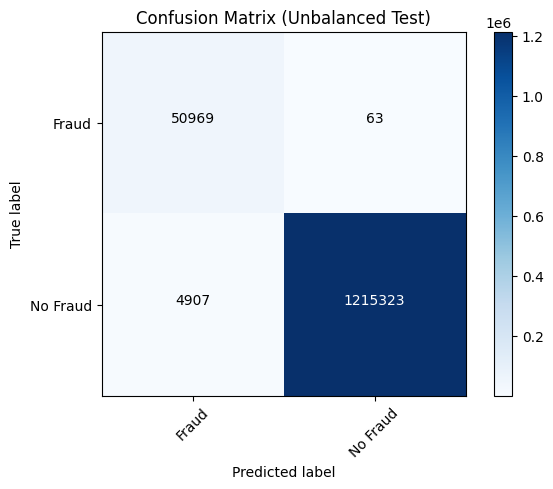

In [0]:
# Plot confusion matrix  
plot_confusion_matrix(cm, "Confusion Matrix (Unbalanced Test)")

In [0]:
# Get or create experiment by name
experiment_name = "/Users/duc.vu@walgreens.com/databricks_use_cases"  # Update this path as needed
mlflow.set_experiment(experiment_name)
experiment = mlflow.get_experiment_by_name(experiment_name)
mlflow_experiment_id = experiment.experiment_id

In [0]:
mlflow_experiment_id

'2238681976963906'

In [0]:
# Log MLflow
with mlflow.start_run(experiment_id = mlflow_experiment_id) as run:
  # Log Parameters and metrics
  mlflow.log_param("balanced", "no")
  mlflow.log_metric("PR train", pr_train)
  mlflow.log_metric("AUC train", auc_train)
  mlflow.log_metric("PR test", pr_test)
  mlflow.log_metric("AUC test", auc_test)
  
  # Log model
  mlflow.spark.log_model(dt_model, "model")
  
  # Log Confusion matrix
  mlflow.log_artifact("confusion-matrix.png")

2025/11/07 18:25:20 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


2025/11/07 18:25:47 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/2238681976963906/2a89a1242f764636907823782bcded3d/artifacts/model/sparkml, flavor: spark). Fall back to return ['pyspark==3.5.0']. Set logging level to DEBUG to see the full traceback. 


In [0]:
# Reset the DataFrames for no fraud (`dfn`) and fraud (`dfy`)
dfn = train.filter(train.label == 0)
dfy = train.filter(train.label == 1)

# Calculate summary metrics
N = train.count()
y = dfy.count()
p = y/N

# Create a more balanced training dataset
train_b = dfn.sample(False, p, seed = 92285).union(dfy)

# Print out metrics
print("Total count: %s, Fraud cases count: %s, Proportion of fraud cases: %s" % (N, y, p))
print("Balanced training dataset count: %s" % train_b.count())

Total count: 5091358, Fraud cases count: 204608, Proportion of fraud cases: 0.040187313482964664
Balanced training dataset count: 400228


In [0]:
# Display our more balanced training dataset
display(train_b.groupBy("label").count())

label,count
0,195620
1,204608


Databricks visualization. Run in Databricks to view.

## Update ML pipeline
Because we had created the ML pipeline stages in the previous cells, we can re-use them to execute it against our balanced dataset.

Note, we are using evaluatorAUC as our evaluator as this is often better for a balanced distribution.

In [0]:
# Re-run the same ML pipeline (including parameters grid)
crossval_b = CrossValidator(estimator = dt,
                          estimatorParamMaps = paramGrid,
                          evaluator = evaluatorAUC,
                          numFolds = 3)  

pipelineCV_b = Pipeline(stages=[indexer, va, crossval_b])

# Train the model using the pipeline, parameter grid, and BinaryClassificationEvaluator using the `train_b` dataset
cvModel_b = pipelineCV_b.fit(train_b)

In [0]:
# Build the best model (balanced training and full test datasets)
train_pred_b = cvModel_b.transform(train_b)
test_pred_b = cvModel_b.transform(test)

# Evaluate the model on the balanced training datasets
pr_train_b = evaluatorPR.evaluate(train_pred_b)
auc_train_b = evaluatorAUC.evaluate(train_pred_b)

# Evaluate the model on full test datasets
pr_test_b = evaluatorPR.evaluate(test_pred_b)
auc_test_b = evaluatorAUC.evaluate(test_pred_b)

# Print out the PR and AUC values
print("PR train:", pr_train_b)
print("AUC train:", auc_train_b)
print("PR test:", pr_test_b)
print("AUC test:", auc_test_b)

PR train: 0.9949452752709911
AUC train: 0.9973177972360091
PR test: 0.8888635827735407
AUC test: 0.9973187933718128


In [0]:
# Create temporary view for test predictions
test_pred_b.createOrReplaceTempView("test_pred_b")

# Create test predictions confusion matrix
test_pred_b_cmdf = spark.sql("select a.label, a.prediction, coalesce(b.count, 0) as count from cmt a left outer join (select label, prediction, count(1) as count from test_pred_b group by label, prediction) b on b.label = a.label and b.prediction = a.prediction order by a.label desc, a.prediction desc")

# View confusion matrix
display(test_pred_b_cmdf)

label,prediction,count
1,1,51025
1,0,7
0,1,6376
0,0,1213854


In [0]:

# Convert to pandas
cm_b_pdf = test_pred_b_cmdf.toPandas()

# Create 1d numpy array of confusion matrix values
cm_b_1d = cm_b_pdf.iloc[:, 2].to_numpy()

# Create 2d numpy array of confusion matrix vlaues
cm_b = np.reshape(cm_b_1d, (-1, 2))

# Print out the 2d array
print(cm_b)

[[  51025       7]
 [   6376 1213854]]


## View Decision Tree Models
Visually compare the differences between the unbalanced and balanced decision tree models (basd on the train and train_b datasets respectively).

In [0]:
# Extract Feature Importance
#  Attribution: Feature Selection Using Feature Importance Score - Creating a PySpark Estimator
#               https://www.timlrx.com/2018/06/19/feature-selection-using-feature-importance-score-creating-a-pyspark-estimator/
import pandas as pd

def ExtractFeatureImp(featureImp, dataset, featuresCol):
    list_extract = []
    for i in dataset.schema[featuresCol].metadata["ml_attr"]["attrs"]:
        list_extract = list_extract + dataset.schema[featuresCol].metadata["ml_attr"]["attrs"][i]
    varlist = pd.DataFrame(list_extract)
    varlist['score'] = varlist['idx'].apply(lambda x: featureImp[x])
    return(varlist.sort_values('score', ascending = False))

In [0]:
# View the Unbalanced Decision Tree model (prior to CrossValidator)
dt_model = pipeline.fit(train)
display(dt_model.stages[-1])

treeNode
"{""index"":13,""featureType"":""continuous"",""prediction"":null,""threshold"":-55621.0,""categories"":null,""feature"":6,""overflow"":false}"
"{""index"":1,""featureType"":""continuous"",""prediction"":null,""threshold"":25.535,""categories"":null,""feature"":3,""overflow"":false}"
"{""index"":0,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":7,""featureType"":""continuous"",""prediction"":null,""threshold"":8243746.3100000005,""categories"":null,""feature"":2,""overflow"":false}"
"{""index"":3,""featureType"":""continuous"",""prediction"":null,""threshold"":727732.8200000001,""categories"":null,""feature"":1,""overflow"":false}"
"{""index"":2,""featureType"":null,""prediction"":0.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":5,""featureType"":""continuous"",""prediction"":null,""threshold"":2338888.425,""categories"":null,""feature"":2,""overflow"":false}"
"{""index"":4,""featureType"":null,""prediction"":0.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":6,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":9,""featureType"":""continuous"",""prediction"":null,""threshold"":727732.8200000001,""categories"":null,""feature"":1,""overflow"":false}"


In [0]:
# Extract Feature Importance for the original unbalanced dt_model
ExtractFeatureImp(dt_model.stages[-1].featureImportances, train_pred, "features").head(10)

,idx,name,vals,score
5,6,orgDiff,NaN,0.609743
2,3,newbalanceOrig,NaN,0.383665
4,5,newbalanceDest,NaN,0.005559
1,2,oldbalanceOrg,NaN,0.000800
0,1,amount,NaN,0.000211
7,0,typeIndexed,"[CASH_OUT, PAYMENT, CASH_IN, TRANSFER, DEBIT]",0.000017
3,4,oldbalanceDest,NaN,0.000005
6,7,destDiff,NaN,0.000000


In [0]:
# View the Balanced Decision Tree model (prior to CrossValidator)
dt_model_b = pipeline.fit(train_b)
display(dt_model_b.stages[-1])

treeNode
"{""index"":15,""featureType"":""continuous"",""prediction"":null,""threshold"":-53760.0,""categories"":null,""feature"":6,""overflow"":false}"
"{""index"":7,""featureType"":""continuous"",""prediction"":null,""threshold"":39.835,""categories"":null,""feature"":3,""overflow"":false}"
"{""index"":1,""featureType"":""continuous"",""prediction"":null,""threshold"":57415.024999999994,""categories"":null,""feature"":2,""overflow"":false}"
"{""index"":0,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":3,""featureType"":""continuous"",""prediction"":null,""threshold"":1.495,""categories"":null,""feature"":3,""overflow"":false}"
"{""index"":2,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":5,""featureType"":""continuous"",""prediction"":null,""threshold"":80555.0,""categories"":null,""feature"":2,""overflow"":false}"
"{""index"":4,""featureType"":null,""prediction"":0.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":6,""featureType"":null,""prediction"":1.0,""threshold"":null,""categories"":null,""feature"":null,""overflow"":false}"
"{""index"":9,""featureType"":""continuous"",""prediction"":null,""threshold"":946677.285,""categories"":null,""feature"":1,""overflow"":false}"


In [0]:
# Extract Feature Importance for the nbalanced dt_model
ExtractFeatureImp(dt_model_b.stages[-1].featureImportances, train_pred_b, "features").head(10)

,idx,name,vals,score
5,6,orgDiff,NaN,9.380881e-01
2,3,newbalanceOrig,NaN,4.739197e-02
4,5,newbalanceDest,NaN,1.031709e-02
0,1,amount,NaN,2.204567e-03
1,2,oldbalanceOrg,NaN,1.262234e-03
7,0,typeIndexed,"[CASH_OUT, TRANSFER, PAYMENT, CASH_IN, DEBIT]",7.257472e-04
6,7,destDiff,NaN,1.002100e-05
3,4,oldbalanceDest,NaN,2.427615e-07


## Comparing Confusion Matrices
Below we will compare the unbalanced and balanced decision tree ML model confusion matrices.

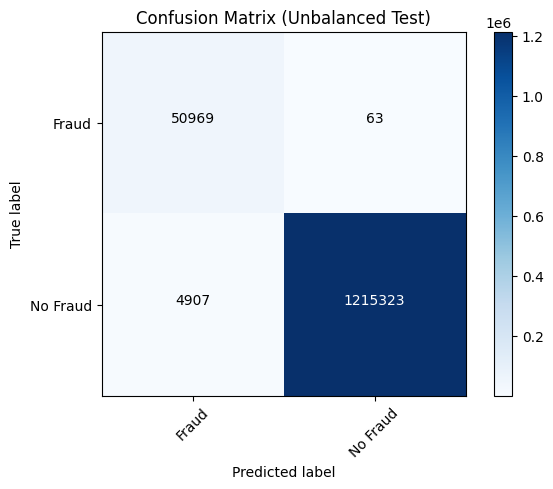

In [0]:
# Plot confusion matrix  
plot_confusion_matrix(cm, "Confusion Matrix (Unbalanced Test)")

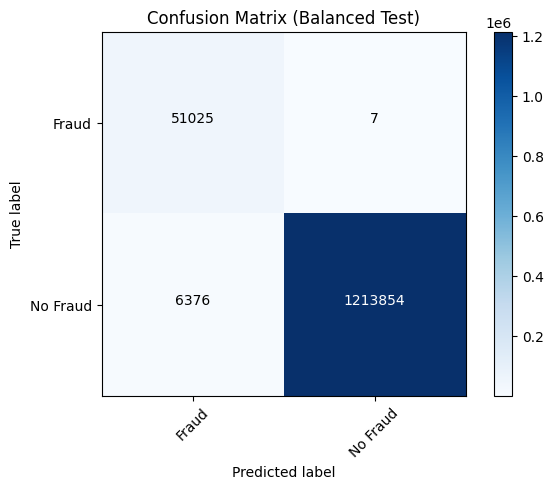

In [0]:
# Plot confusion matrix  
plot_confusion_matrix(cm_b, "Confusion Matrix (Balanced Test)")

In [0]:
# Log MLflow
with mlflow.start_run(experiment_id = mlflow_experiment_id) as run:
  # Log Parameters and metrics
  mlflow.log_param("balanced", "yes")
  mlflow.log_metric("PR train", pr_train_b)
  mlflow.log_metric("AUC train", auc_train_b)
  mlflow.log_metric("PR test", pr_test_b)
  mlflow.log_metric("AUC test", auc_test_b)
    
  # Log model
  mlflow.spark.log_model(dt_model_b, "model")
  
  # Log Confusion matrix
  mlflow.log_artifact("confusion-matrix.png")

2025/11/07 18:34:03 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


2025/11/07 18:34:30 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/2238681976963906/839187568e124322859f5fa36d3d754c/artifacts/model/sparkml, flavor: spark). Fall back to return ['pyspark==3.5.0']. Set logging level to DEBUG to see the full traceback. 


## Observation
There is a significant difference for the PR and AUC values when comparing the unbalanced vs. balanced decision tree models.

|Metric/dataset|	Unbalanced|	Balanced|
|------------------|------------------|------------------|
|PR train	|0.9537894984523128	|0.999629161563572|
|AUC train	|0.998647996459481	|0.9998071389056655|
|PR test	|0.9539170535377599	|0.9904709171789063|
|AUC test	|0.9984378183482442	|0.9997903902204509|
